# Sales Analysis Capstone Project

This project analyzes sales performance data and answer some questions my manager has asked me for the South Carolina and Southeast sales territories in the South Region 

The questions I will be answering are:

∗ Who are the territory managers for the sales territories assigned? What are the store IDs and cities 
for the stores in each assigned sales territory? 

∗ What is monthly total revenue for in-store sales in each of the two sales territories, over the full 
period covered by the data? 

∗ How would you rank the sales performance of each store in each sales territory? Which are the 
top-performing stores? 

∗ Comparing the customer ID from the customer list data with the rewards ID from the sales data, 
who were the top customers in each sales territory? 

∗ What is the number of transactions per month by product category in each assigned territory? 
What is total sales revenue per month by category? What might this tell you about the most 
popular products, and where could there be opportunity for growth? 

∗ What is your recommendation for where to focus marketing attention in the next quarter? 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
storesales_df = pd.read_csv("StoreSales.csv")

storesales_df.info()
storesales_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 335129 entries, 0 to 335128
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction Date  335129 non-null  object 
 1   Store ID          335129 non-null  int64  
 2   RewardsID         34943 non-null   float64
 3   Prod Num          335129 non-null  object 
 4   Sale Amount       335129 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 12.8+ MB


,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount
0,1/1/2022,702,NaN,105349-M,8.00
1,1/1/2022,704,NaN,105350-T,144.00
2,1/1/2022,705,NaN,105351-M,44.00
3,1/1/2022,705,NaN,105352-M,47.61
4,1/1/2022,705,NaN,105353-A,20.36


In [6]:
storedetail_df = pd.read_csv("StoreDetail.csv")

storedetail_df.info()
storedetail_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Store Location     111 non-null    object
 1   State              111 non-null    object
 2   Store ID           111 non-null    int64 
 3   Territory Manager  111 non-null    object
 4   Region             111 non-null    object
 5   Region Director    111 non-null    object
dtypes: int64(1), object(5)
memory usage: 5.3+ KB


,Store Location,State,Store ID,Territory Manager,Region,Region Director
0,Aurora,Colorado,701,Jim Heck,West,Cassie Chambers
1,Berthoud,Colorado,702,Jim Heck,West,Cassie Chambers
2,Boulder,Colorado,703,Jim Heck,West,Cassie Chambers
3,Castle Rock,Colorado,704,Jim Heck,West,Cassie Chambers
4,Denver,Colorado,705,Jim Heck,West,Cassie Chambers


In [7]:
products_df = pd.read_csv("Products.csv")

products_df.info()
products_df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 669 entries, 0 to 668
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Prod Num       669 non-null    object
 1   Product        669 non-null    object
 2   CategoryID     669 non-null    int64 
 3   SubcategoryID  669 non-null    object
dtypes: int64(1), object(3)
memory usage: 21.0+ KB


,Prod Num,Product,CategoryID,SubcategoryID
0,105248-IT,TCL NXTPAPER 10s,120,120-tab
1,105249-IT,Dell Latitude 7320 Detachable,120,120-tab
2,105250-IT,Realme Pad,120,120-tab
3,105251-IT,Lenovo Tab P12 Pro,120,120-tab
4,105252-IT,Microsoft Surface Pro 9,120,120-tab


In [8]:
productcategories_df = pd.read_csv("ProductCategories.csv")

productcategories_df.info()
productcategories_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CategoryID     52 non-null     int64 
 1   Category       52 non-null     object
 2   SubcategoryID  52 non-null     object
 3   Subcategory    52 non-null     object
dtypes: int64(1), object(3)
memory usage: 1.8+ KB


,CategoryID,Category,SubcategoryID,Subcategory
0,120,Technology & Accessories,120-tab,Tablets
1,120,Technology & Accessories,120-cal,Calculators
2,120,Technology & Accessories,120-sof,Software Download
3,120,Technology & Accessories,120-hea,Headphones
4,120,Technology & Accessories,120-ext,External Accessories


In [77]:
customerlist_df = pd.read_csv("customer_list.csv", sep="|")

customerlist_df.info()
customerlist_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   cust_id       521 non-null    int64 
 1   date          521 non-null    object
 2   time          521 non-null    object
 3   name          521 non-null    object
 4   email         521 non-null    object
 5   phone         520 non-null    object
 6   sms-opt-out   520 non-null    object
dtypes: int64(1), object(6)
memory usage: 28.6+ KB


,cust_id,date,time,name,email,phone,sms-opt-out
0,1,2023-03-15,08:45:12,Rachel,rachel@centralperk.coffee,212-555-1001,N
1,2,2023-05-22,12:30:45,R. Geller,rossg@centralperk.coffee,212-555-1002,N
2,3,2023-07-09,18:15:27,Monica Geller,chefmonica@centralperk.coffee,212-555-1003,N
3,4,2023-09-01,21:05:33,Chandler Bing,chandlerb@centralperk.coffee,212-555-1004,Y
4,5,2023-11-18,14:22:10,Joey,howyoudoing@centralperk.coffee,212-555-1005,N


# Core Marketing Analysis

## Territory Managers and Store Locations

Who are the territory managers for the sales territories assigned? What are the store IDs and cities for the stores in each assigned sales territory?

Len Jensen is the territory manager for South Carolina with store IDs 852 and 853

Jeff "Howdy" Richards is the territory manager for Texas with store  901, 902, 903, 904, 905, 906, 907, 908, 909, 910, and 911

In [80]:
territory_info = storedetail_df[
    storedetail_df["State"].isin(
        ["South Carolina", "Texas"]
    )
]

territory_summary = territory_info[["Store ID", "Store Location", "State", "Territory Manager"]
]

territory_summary.sort_values(
    by = ["Store ID"]
)

,Store ID,Store Location,State,Territory Manager
98,852,Charleston,South Carolina,Len Jensen
99,853,Greenville,South Carolina,Len Jensen
100,901,Arlington,Texas,"Jeff ""Howdy"" Richards"
101,902,Austin,Texas,"Jeff ""Howdy"" Richards"
102,903,Bacliff,Texas,"Jeff ""Howdy"" Richards"
103,904,Baytown,Texas,"Jeff ""Howdy"" Richards"
104,905,Beaumont,Texas,"Jeff ""Howdy"" Richards"
105,906,Cedar Park,Texas,"Jeff ""Howdy"" Richards"
106,907,Dallas,Texas,"Jeff ""Howdy"" Richards"
107,908,Denton,Texas,"Jeff ""Howdy"" Richards"


## Monthly Total Revenue
What is monthly total revenue for in-store sales in each of South Carolina and Texas territories, over the full period covered by the data?

In [81]:
storesales_df["Transaction Date"] = pd.to_datetime(
    storesales_df["Transaction Date"]
)

salesperterritory = storesales_df.merge(
    territory_info[["Store ID", "State", "Store Location"]],
    on= "Store ID",
    how= "left"
)

salesperterritory["Month"] = (
    salesperterritory["Transaction Date"]
    .dt.to_period("M")
)

monthly_revenue = salesperterritory.groupby(
    ["State", "Month", "Store Location"]
)["Sale Amount"].sum().reset_index()

monthly_revenue


,State,Month,Store Location,Sale Amount
0,South Carolina,2022-01,Charleston,7129.58
1,South Carolina,2022-01,Greenville,2510.80
2,South Carolina,2022-02,Charleston,6473.06
3,South Carolina,2022-02,Greenville,3290.92
4,South Carolina,2022-03,Charleston,3857.51
...,...,...,...,...
585,Texas,2025-12,Cedar Park,10234.46
586,Texas,2025-12,Denton,11252.43
587,Texas,2025-12,Desoto,4691.92
588,Texas,2025-12,Fort Worth,6173.99


## Store Peformance Ranking

How would you rank the sales performance of each store in each sales territory? Which are the 
top-performing stores?

The top performing store in South Carolina is store 853 in Greenville

The top performing store in Texas is store 905 in Beaumont

In [112]:
store_performance = salesperterritory.groupby(
    ["State", "Store ID", "Store Location"]
)["Sale Amount"].sum().reset_index()

store_performance["Rank"] = (
    store_performance.groupby("State")
    ["Sale Amount"].rank(ascending = False)
)

store_performance.sort_values(
    by = ["State", "Rank"]
)

,State,Store ID,Store Location,Sale Amount,Rank
1,South Carolina,853,Greenville,337002.00,1.0
0,South Carolina,852,Charleston,311810.56,2.0
6,Texas,905,Beaumont,637818.90,1.0
11,Texas,910,Fort Worth,351772.59,2.0
10,Texas,909,Desoto,330720.12,3.0
7,Texas,906,Cedar Park,312628.27,4.0
5,Texas,904,Baytown,298163.16,5.0
9,Texas,908,Denton,298111.45,6.0
2,Texas,901,Arlington,292987.49,7.0
3,Texas,902,Austin,291145.00,8.0


In [83]:
top_stores = store_performance[
    store_performance["Rank"] == 1
]

top_stores

,State,Store ID,Store Location,Sale Amount,Rank
1,South Carolina,853,Greenville,337002.0,1.0
6,Texas,905,Beaumont,637818.9,1.0


## Top Customers by Territory
Comparing the customer ID from the customer list data with the rewards ID from the sales data, 
who were the top customers in each sales territory? 

The top customer for South Carolina is Jin Kwon with $1786.05 total spent

The top customer for Texas is Nate Jacobs with $5240.86 total spent

In [101]:
customer_sales = salesperterritory.merge(
    customerlist_df, 
    left_on= "RewardsID",
    right_on= "cust_id",
    how="left"
)

filtered_sales = customer_sales[
    customer_sales["State"].isin(["South Carolina"])
]

top_customers = filtered_sales.groupby(
    ["State", "cust_id", "name"]
)["Sale Amount"].sum().reset_index()

top_customers = top_customers.sort_values(
    by= "Sale Amount",
    ascending=False
)


top_customers.head(10)

,State,cust_id,name,Sale Amount
186,South Carolina,340.0,Jin Kwon,1786.05
229,South Carolina,404.0,Roman Roy,1778.84
122,South Carolina,213.0,Jazz,1763.70
42,South Carolina,74.0,Ben Chang,1566.60
157,South Carolina,280.0,Cal Abar,1396.50
131,South Carolina,227.0,Debra Morgan,1388.56
7,South Carolina,10.0,Emily,1365.72
143,South Carolina,243.0,Dayanara Diaz,1359.30
31,South Carolina,48.0,Andy B.,1334.92
275,South Carolina,478.0,AJ Soprano,1322.16


In [107]:
customer_sales = salesperterritory.merge(
    customerlist_df, 
    left_on = "RewardsID",
    right_on = "cust_id",
    how = "left"
)

filtered_sales = customer_sales[
    customer_sales["State"].isin(["Texas"])
]

top_customers = filtered_sales.groupby(
    ["State", "cust_id", "name"]
)["Sale Amount"].sum().reset_index()

top_customers = top_customers.sort_values(
    by = "Sale Amount",
    ascending = False
)


top_customers.head(10)

,State,cust_id,name,Sale Amount
341,Texas,344.0,Nate Jacobs,5240.86
470,Texas,474.0,Christopher Moltisanti,3479.46
100,Texas,102.0,Jodie L.,3464.91
166,Texas,168.0,Darius,3400.35
268,Texas,271.0,Maeby F.,3127.53
482,Texas,486.0,Pete Campbell,2845.84
198,Texas,200.0,Animal,2843.74
387,Texas,390.0,Dot Com,2757.26
259,Texas,262.0,Hollyhock,2715.74
151,Texas,153.0,Chachi A.,2708.13


## Product Category Analysis
What is the number of transactions per month by product category in each assigned territory? 
What is total sales revenue per month by category? What might this tell you about the most 
popular products, and where could there be opportunity for growth? 

In [114]:
sales_products = storesales_df.merge(
    products_df,
    on = "Prod Num",
    how = "left"
)

sales_products = sales_products.merge(
    productcategories_df,
    on = "CategoryID",
    how = "left"
)

sales_products = sales_products.merge(
    storedetail_df[["Store ID", "State"]],
    on = "Store ID",
    how = "left"
)

sales_products["Transaction Date"] = pd.to_datetime(
    sales_products["Transaction Date"]
)

sales_products["Month"] = (
    sales_products["Transaction Date"]
    .dt.to_period("M")
)

In [115]:
transcationpercategory = sales_products.groupby(
    ["State", "Month", "Category"]
).size().reset_index(
    name = "Transaction Count"
)

transcationpercategory


,State,Month,Category,Transaction Count
0,Colorado,2022-01,Apparel and Merchandise,864
1,Colorado,2022-01,Art Supplies,913
2,Colorado,2022-01,Books (General),172
3,Colorado,2022-01,Stationery and Supplies,1232
4,Colorado,2022-01,Technology & Accessories,882
...,...,...,...,...
2875,Texas,2025-12,Art Supplies,1177
2876,Texas,2025-12,Books (General),280
2877,Texas,2025-12,Stationery and Supplies,1870
2878,Texas,2025-12,Technology & Accessories,1183


In [117]:
revenuepercategory = sales_products.groupby(
    ["State", "Month", "Category"]
)["Sale Amount"].sum().reset_index()

revenuepercategory

,State,Month,Category,Sale Amount
0,Colorado,2022-01,Apparel and Merchandise,29059.20
1,Colorado,2022-01,Art Supplies,25118.72
2,Colorado,2022-01,Books (General),3839.12
3,Colorado,2022-01,Stationery and Supplies,13526.26
4,Colorado,2022-01,Technology & Accessories,357604.17
...,...,...,...,...
2875,Texas,2025-12,Art Supplies,39441.93
2876,Texas,2025-12,Books (General),8498.12
2877,Texas,2025-12,Stationery and Supplies,18778.54
2878,Texas,2025-12,Technology & Accessories,492001.58


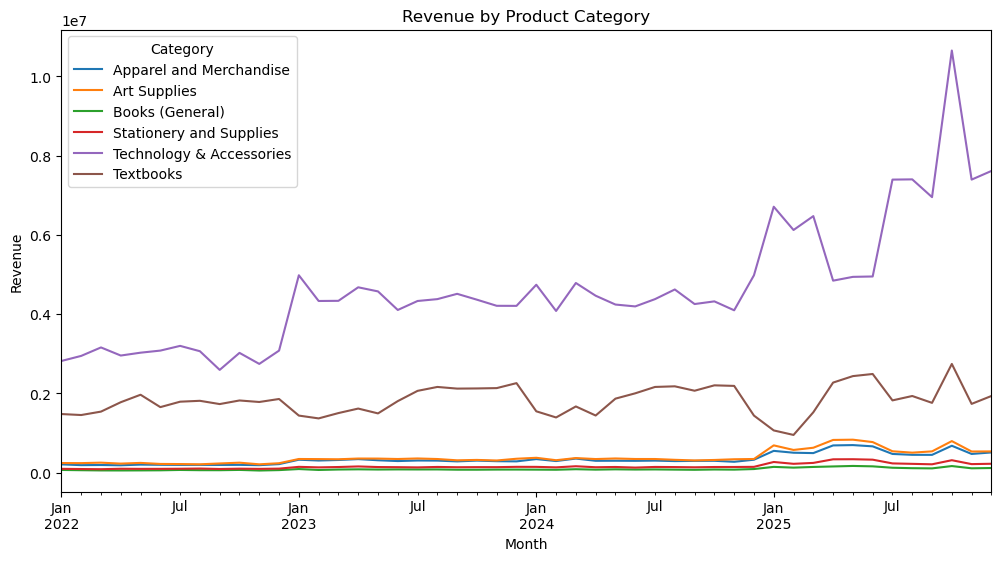

In [120]:
revenuepercategory.pivot_table(
    index = "Month",
    columns = "Category",
    values = "Sale Amount",
    aggfunc = "sum"
).plot(figsize = (12,6))

plt.title("Revenue by Product Category")
plt.ylabel("Revenue")
plt.xlabel("Month")

plt.show()
